# Análise de Acidentes em Rodovias Federais — PRF 2025

**Unidade 5, Módulo 2** | Equipe: Alex Lopes & Thyago Antonio

Este notebook lê a planilha `atividade2_completo.xlsx` e reproduz, passo a passo, todas as
tabelas que sustentam o relatório escrito.

**Como o notebook está organizado:**

1. Preparação do ambiente e leitura da planilha
2. Panorama geral (totais nacionais)
3. Frequências: por UF, por rodovia (BR) e por tipo de acidente
4. Rankings: volume, mortos por 100 mil habitantes, mortos por rodovia e letalidade por tipo
5. Série mensal — a única tabela com gráfico
6. Insights complementares e verificação dos números citados no relatório

**Convenção de exibição:** para todas as tabelas, exibimos os **5 primeiros** e os **5 últimos**
registros. A ideia é mostrar os dois extremos de cada ranking sem poluir o notebook com tabelas
enormes. A única exceção é a **Série Mensal**, que tem apenas 12 linhas e por isso é exibida
inteira, acompanhada de um gráfico.

## 1. Preparação do ambiente

Importamos as bibliotecas e definimos as opções de exibição. Usamos apenas `pandas`
(manipulação de dados) e `matplotlib` (gráfico da série mensal).

In [1]:
# Bibliotecas usadas em todo o notebook
import pandas as pd                 # leitura da planilha e manipulação de tabelas
import matplotlib.pyplot as plt     # gráfico da série mensal (usado só na seção 5)
from pathlib import Path

# Opções de exibição: evita quebra de colunas e padroniza casas decimais
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Bibliotecas carregadas. pandas versão:", pd.__version__)

Bibliotecas carregadas. pandas versão: 3.0.2


## 2. Leitura da planilha

A planilha tem 8 abas. Em **todas** elas a primeira linha do arquivo é o título da aba
(ex.: *"Frequência de Acidentes por UF (IBGE 2025)"*) e os nomes reais das colunas estão na
**segunda linha**. Por isso lemos tudo com `header=1` — sem esse parâmetro o pandas
interpretaria o título como cabeçalho e todas as colunas viriam como `Unnamed: N`.

In [2]:
# Caminho da planilha. Ajuste se o arquivo estiver em outra pasta.
CAMINHO = Path("atividade2_completo.xlsx")

# Procura o arquivo em alguns locais comuns, para o notebook rodar em qualquer máquina
if not CAMINHO.exists():
    for alternativo in [Path("../atividade2_completo.xlsx"),
                        Path("/mnt/user-data/uploads/atividade2_completo.xlsx")]:
        if alternativo.exists():
            CAMINHO = alternativo
            break

print("Usando o arquivo:", CAMINHO.resolve())

# Lista as abas disponíveis antes de carregar qualquer coisa
abas = pd.ExcelFile(CAMINHO).sheet_names
for nome in abas:
    print(" -", nome)

Usando o arquivo: /home/claude/atividade2_completo.xlsx
 - Freq - UF
 - Freq - BR
 - Freq - Tipo
 - Ranking - UF Volume
 - Ranking - UF 100k
 - Ranking - BR Mortos
 - Ranking - Tipo%
 - Série Mensal


In [3]:
def carregar(aba: str) -> pd.DataFrame:
    """Lê uma aba da planilha já com o cabeçalho correto.

    header=1  -> pula a linha de título da aba e usa a 2a linha como nome das colunas
    .dropna(how='all') -> descarta eventuais linhas totalmente vazias no fim da aba
    """
    df = pd.read_excel(CAMINHO, sheet_name=aba, header=1)
    return df.dropna(how="all").reset_index(drop=True)


def extremos(df: pd.DataFrame, titulo: str, n: int = 5) -> None:
    """Exibe os n primeiros e os n últimos registros de uma tabela.

    É o formato que usamos em todas as tabelas do trabalho: mostra o topo e a base
    de cada ranking, que é justamente onde estão as histórias interessantes.
    """
    print("=" * 90)
    print(f"{titulo}  —  {len(df)} registros, {df.shape[1]} colunas")
    print("=" * 90)
    print(f"\n>>> {n} PRIMEIROS registros")
    display(df.head(n))
    print(f">>> {n} ÚLTIMOS registros")
    display(df.tail(n))


# Carrega todas as abas de uma vez em um dicionário
dados = {aba: carregar(aba) for aba in abas}
print("Abas carregadas:", len(dados))

Abas carregadas: 8


## 3. Panorama geral

Antes de olhar qualquer recorte, vale fixar os números nacionais. Todas as abas de frequência
(UF, BR e Tipo) são recortes do **mesmo conjunto de dados**, então elas têm que fechar no mesmo
total. Conferir isso é a primeira validação do trabalho: se os totais não batessem, algum
recorte estaria incompleto.

In [4]:
# Confere se as três frequências somam os mesmos totais
resumo = pd.DataFrame({
    aba: dados[aba][["ACIDENTES", "FATAIS", "MORTOS"]].sum()
    for aba in ["Freq - UF", "Freq - BR", "Freq - Tipo"]
}).T
display(resumo)

# Totais nacionais e indicadores derivados
total_acidentes = int(dados["Freq - UF"]["ACIDENTES"].sum())
total_fatais    = int(dados["Freq - UF"]["FATAIS"].sum())
total_mortos    = int(dados["Freq - UF"]["MORTOS"].sum())

print(f"\nAcidentes registrados em 2025 .............. {total_acidentes:,}".replace(",", "."))
print(f"Acidentes com pelo menos uma morte ........ {total_fatais:,}".replace(",", "."))
print(f"Total de mortos ........................... {total_mortos:,}".replace(",", "."))
print(f"\nLetalidade nacional (fatais/acidentes) .... {total_fatais/total_acidentes:.2%}")
print(f"Mortos por acidente fatal ................. {total_mortos/total_fatais:.2f}")

,ACIDENTES,FATAIS,MORTOS
Freq - UF,72529,5209,6043
Freq - BR,72529,5209,6043
Freq - Tipo,72529,5209,6043



Acidentes registrados em 2025 .............. 72.529
Acidentes com pelo menos uma morte ........ 5.209
Total de mortos ........................... 6.043

Letalidade nacional (fatais/acidentes) .... 7.18%
Mortos por acidente fatal ................. 1.16


> **Atenção a uma armadilha de interpretação.** A coluna `PCT FATAL` é
> `FATAIS / ACIDENTES`, ou seja, o percentual de acidentes que resultaram em **pelo menos uma**
> morte. Ela **não** é `MORTOS / ACIDENTES`. Como um mesmo acidente pode matar mais de uma
> pessoa, os dois cálculos dão resultados diferentes (7,18% contra 8,33% no total nacional).
> Ao longo do relatório, sempre que dissermos "taxa de letalidade" estamos falando da primeira
> definição.

## 4. Frequências

### 4.1 Frequência por UF

Cada linha é um estado, com população (IBGE 2025), acidentes, acidentes fatais, mortos e as
taxas já padronizadas por 100 mil habitantes. A aba vem **ordenada alfabeticamente** pela UF —
por isso os "5 primeiros" aqui são AC, AL, AM, AP e BA, e não os estados mais perigosos.

In [5]:
uf = dados["Freq - UF"]
extremos(uf, "Frequência de Acidentes por UF")

Frequência de Acidentes por UF  —  27 registros, 9 colunas

>>> 5 PRIMEIROS registros


,UF,POPULACAO,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
0,AC,884372,280,0.00,29,29,0.10,31.70,3.30
1,AL,3220848,629,0.01,86,96,0.14,19.50,3.00
2,AM,4321616,138,0.00,19,26,0.14,3.20,0.60
3,AP,806517,169,0.00,9,14,0.05,21.00,1.70
4,BA,14870907,4108,0.06,476,583,0.12,27.60,3.90


>>> 5 ÚLTIMOS registros


,UF,POPULACAO,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
22,RS,11233263,4899,0.07,275,327,0.06,43.60,2.90
23,SC,8187029,8186,0.11,374,434,0.05,100.00,5.30
24,SE,2299425,589,0.01,44,51,0.07,25.60,2.20
25,SP,46081801,4683,0.07,205,221,0.04,10.20,0.50
26,TO,1586859,677,0.01,83,102,0.12,42.70,6.40


### 4.2 Frequência por rodovia (BR)

Cada linha é uma rodovia federal. São 115 rodovias, ordenadas pelo número da BR. Essa aba
não foi explorada na primeira versão do relatório e, como veremos na seção 6, é onde estão
alguns dos achados mais úteis para uma política pública.

In [6]:
br = dados["Freq - BR"]
extremos(br, "Frequência de Acidentes por Rodovia (BR)")

Frequência de Acidentes por Rodovia (BR)  —  115 registros, 6 colunas

>>> 5 PRIMEIROS registros


,BR,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL
0,0,167,0.00,0,0,0.00
1,10,506,0.01,86,95,0.17
2,20,699,0.01,55,69,0.08
3,30,4,0.00,2,2,0.50
4,40,3502,0.05,180,214,0.05


>>> 5 ÚLTIMOS registros


,BR,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL
110,485,2,0.00,0,0,0.00
111,487,49,0.00,5,10,0.10
112,488,33,0.00,1,1,0.03
113,493,369,0.01,21,23,0.06
114,495,32,0.00,0,0,0.00


### 4.3 Frequência por tipo de acidente

Aqui está a natureza da colisão: traseira, frontal, atropelamento, tombamento e assim por
diante. São 17 tipos, ordenados alfabeticamente.

In [7]:
tipo = dados["Freq - Tipo"]
extremos(tipo, "Frequência de Acidentes por Tipo")

Frequência de Acidentes por Tipo  —  17 registros, 6 colunas

>>> 5 PRIMEIROS registros


,TIPO ACIDENTE,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL
0,Atropelamento de Animal,1133,0.02,68,74,0.06
1,Atropelamento de Pedestre,3057,0.04,902,919,0.29
2,Capotamento,1373,0.02,63,74,0.05
3,Colisão com objeto,5109,0.07,297,323,0.06
4,Colisão frontal,4739,0.07,1395,1863,0.29


>>> 5 ÚLTIMOS registros


,TIPO ACIDENTE,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL
12,Incêndio,1771,0.02,0,0,0.00
13,Queda de ocupante de veículo,3450,0.05,87,89,0.03
14,Saída de leito carroçável,10209,0.14,605,700,0.06
15,Sinistro pessoal de trânsito,7,0.00,0,0,0.00
16,Tombamento,6351,0.09,268,293,0.04


## 5. Rankings

As abas de ranking contêm os mesmos dados das abas de frequência, porém **já ordenados** por um
critério específico. É por isso que, nelas, os 5 primeiros e os 5 últimos registros são
exatamente o topo e a base de cada ranking.

### 5.1 Ranking por UF — volume de acidentes

Ordenado do estado com mais acidentes para o com menos, em números absolutos.

In [8]:
extremos(dados["Ranking - UF Volume"], "Ranking por UF — Volume de Acidentes")

Ranking por UF — Volume de Acidentes  —  27 registros, 8 colunas

>>> 5 PRIMEIROS registros


,UF,POPULACAO,ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
0,MG,21393441,9570,647,765,0.07,44.70,3.60
1,SC,8187029,8186,374,434,0.05,100.00,5.30
2,PR,11890517,7630,511,593,0.07,64.20,5.00
3,RJ,17223547,6428,306,330,0.05,37.30,1.90
4,RS,11233263,4899,275,327,0.06,43.60,2.90


>>> 5 ÚLTIMOS registros


,UF,POPULACAO,ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
22,SE,2299425,589,44,51,0.07,25.60,2.20
23,AC,884372,280,29,29,0.10,31.70,3.30
24,AP,806517,169,9,14,0.05,21.00,1.70
25,RR,738772,142,23,28,0.16,19.20,3.80
26,AM,4321616,138,19,26,0.14,3.20,0.60


### 5.2 Ranking por UF — mortos por 100 mil habitantes

Este é o indicador mais justo para comparar estados, porque desconta o tamanho da população.
É a diferença entre "onde acontecem mais mortes" e "onde um morador corre mais risco".

In [9]:
extremos(dados["Ranking - UF 100k"], "Ranking por UF — Mortos por 100 mil habitantes")

Ranking por UF — Mortos por 100 mil habitantes  —  27 registros, 8 colunas

>>> 5 PRIMEIROS registros


,UF,POPULACAO,ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
0,TO,1586859,677,83,102,0.12,42.70,6.40
1,MT,3893659,2636,204,243,0.08,67.70,6.20
2,RO,1751950,1452,86,102,0.06,82.90,5.80
3,SC,8187029,8186,374,434,0.05,100.00,5.30
4,MS,2924631,1654,136,150,0.08,56.60,5.10


>>> 5 ÚLTIMOS registros


,UF,POPULACAO,ACIDENTES,FATAIS,MORTOS,PCT FATAL,ACIDENTES POR 100K,MORTOS POR 100K
22,CE,9268836,1302,152,171,0.12,14.00,1.80
23,AP,806517,169,9,14,0.05,21.00,1.70
24,DF,2996899,1011,43,47,0.04,33.70,1.60
25,AM,4321616,138,19,26,0.14,3.20,0.60
26,SP,46081801,4683,205,221,0.04,10.20,0.50


### 5.3 Ranking por rodovia — total de mortos

Ordenado pelo número absoluto de mortos em cada BR.

In [10]:
extremos(dados["Ranking - BR Mortos"], "Ranking por BR — Total de Mortos")

Ranking por BR — Total de Mortos  —  115 registros, 5 colunas

>>> 5 PRIMEIROS registros


,BR,ACIDENTES,FATAIS,MORTOS,PCT FATAL
0,101,13014,682,760,0.05
1,116,11021,637,708,0.06
2,153,2789,226,282,0.08
3,40,3502,180,214,0.05
4,163,2519,173,210,0.07


>>> 5 ÚLTIMOS registros


,BR,ACIDENTES,FATAIS,MORTOS,PCT FATAL
110,431,1,0,0,0.00
111,469,55,0,0,0.00
112,484,1,0,0,0.00
113,485,2,0,0,0.00
114,495,32,0,0,0.00


### 5.4 Ranking por tipo — proporção de acidentes fatais

Ordenado pela letalidade de cada tipo de acidente. Responde à pergunta: *dado que o acidente
aconteceu, qual a chance de alguém morrer?*

In [11]:
extremos(dados["Ranking - Tipo%"], "Ranking por Tipo — Proporção Fatal")

Ranking por Tipo — Proporção Fatal  —  17 registros, 5 colunas

>>> 5 PRIMEIROS registros


,TIPO ACIDENTE,ACIDENTES,FATAIS,MORTOS,PCT FATAL
0,Atropelamento de Pedestre,3057,902,919,0.29
1,Colisão frontal,4739,1395,1863,0.29
2,Colisão lateral sentido oposto,2152,212,255,0.10
3,Eventos atípicos,287,23,24,0.08
4,Atropelamento de Animal,1133,68,74,0.06


>>> 5 ÚLTIMOS registros


,TIPO ACIDENTE,ACIDENTES,FATAIS,MORTOS,PCT FATAL
12,Colisão lateral mesmo sentido,7885,212,228,0.03
13,Queda de ocupante de veículo,3450,87,89,0.03
14,Engavetamento,1233,28,34,0.02
15,Incêndio,1771,0,0,0.00
16,Sinistro pessoal de trânsito,7,0,0,0.00


## 6. Série mensal (única tabela com gráfico)

A série mensal tem só 12 linhas, então não faz sentido cortá-la em primeiros e últimos: exibimos
a tabela completa. Em compensação, é a única tabela com uma dimensão temporal — e é aí que um
gráfico realmente acrescenta alguma coisa que a tabela sozinha não mostra.

In [12]:
mes = dados["Série Mensal"].copy()

# Rótulo curto de mês para o eixo do gráfico (2025-01 -> Jan)
NOMES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
         "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
mes["MES_LABEL"] = NOMES

display(mes)

# Estatísticas rápidas da série
print("Mês com mais acidentes:", mes.loc[mes["ACIDENTES"].idxmax(), "MES"],
      "-", f'{mes["ACIDENTES"].max():,}'.replace(",", "."))
print("Mês com menos acidentes:", mes.loc[mes["ACIDENTES"].idxmin(), "MES"],
      "-", f'{mes["ACIDENTES"].min():,}'.replace(",", "."))
print("Mês mais letal (maior % fatal):", mes.loc[mes["PCT FATAL"].idxmax(), "MES"],
      "-", f'{mes["PCT FATAL"].max():.1%}')
print(f'\n1o semestre: {mes.head(6)["ACIDENTES"].sum():,} acidentes e '
      f'{mes.head(6)["MORTOS"].sum():,} mortos'.replace(",", "."))
print(f'2o semestre: {mes.tail(6)["ACIDENTES"].sum():,} acidentes e '
      f'{mes.tail(6)["MORTOS"].sum():,} mortos'.replace(",", "."))

,MES,ACIDENTES,FATAIS,MORTOS,PCT FATAL,MES_LABEL
0,2025-01,5528,358,418,0.07,Jan
1,2025-02,5287,362,412,0.07,Fev
2,2025-03,5960,402,462,0.07,Mar
3,2025-04,5786,414,495,0.07,Abr
4,2025-05,6096,504,574,0.08,Mai
5,2025-06,6122,457,528,0.07,Jun
6,2025-07,6238,456,536,0.07,Jul
7,2025-08,6246,472,554,0.08,Ago
8,2025-09,6017,438,500,0.07,Set
9,2025-10,6252,422,494,0.07,Out


Mês com mais acidentes: 2025-12 - 6.788
Mês com menos acidentes: 2025-02 - 5.287
Mês mais letal (maior % fatal): 2025-05 - 8.3%

1o semestre: 34.779 acidentes e 2.889 mortos
2o semestre: 37.750 acidentes e 3.154 mortos


O gráfico abaixo combina duas informações que contam histórias diferentes:

- **Barras (eixo da esquerda):** volume de acidentes no mês — mostra a sazonalidade do tráfego.
- **Linha (eixo da direita):** taxa de letalidade do mês — mostra a gravidade.

Juntar as duas coisas no mesmo gráfico deixa visível que **o mês de maior volume não é o mês
mais letal**, que é exatamente o argumento central do relatório aplicado ao tempo em vez do
espaço.

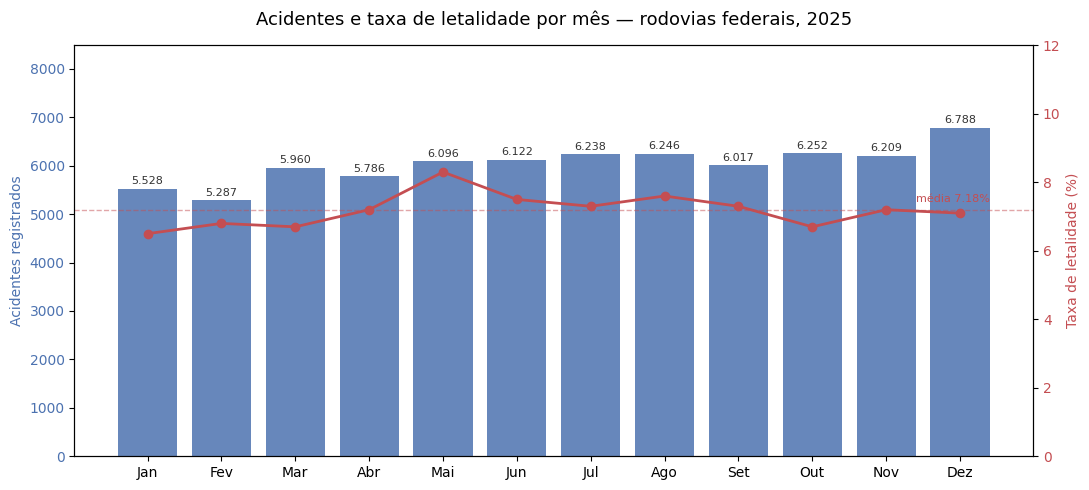

In [13]:
fig, ax1 = plt.subplots(figsize=(11, 5))

# --- Eixo esquerdo: barras com o volume de acidentes ---
ax1.bar(mes["MES_LABEL"], mes["ACIDENTES"],
        color="#4C72B0", alpha=0.85, label="Acidentes")
ax1.set_ylabel("Acidentes registrados", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")
ax1.set_ylim(0, mes["ACIDENTES"].max() * 1.25)   # folga no topo para os rótulos

# Rótulo com o valor em cima de cada barra
for x, v in zip(mes["MES_LABEL"], mes["ACIDENTES"]):
    ax1.text(x, v + 90, f"{v:,}".replace(",", "."),
             ha="center", fontsize=8, color="#333333")

# --- Eixo direito: linha com a taxa de letalidade ---
ax2 = ax1.twinx()
ax2.plot(mes["MES_LABEL"], mes["PCT FATAL"] * 100,
         color="#C44E52", marker="o", linewidth=2, label="Letalidade (%)")
ax2.set_ylabel("Taxa de letalidade (%)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")
ax2.set_ylim(0, 12)

# Linha de referência com a média nacional do ano
media = total_fatais / total_acidentes * 100
ax2.axhline(media, color="#C44E52", linestyle="--", linewidth=1, alpha=0.5)
ax2.text(11.4, media + 0.25, f"média {media:.2f}%",
         color="#C44E52", fontsize=8, ha="right")

plt.title("Acidentes e taxa de letalidade por mês — rodovias federais, 2025",
          fontsize=13, pad=15)
fig.tight_layout()
plt.show()

## 7. Insights complementares

Esta seção calcula os números que sustentam as descobertas novas do relatório — as que não
apareciam na primeira versão.

### 7.1 O tipo de acidente importa mais do que o estado

Volume e letalidade seguem lógicas opostas também quando olhamos *como* o acidente aconteceu.

In [14]:
analise_tipo = tipo.copy()
analise_tipo["% DOS ACIDENTES"] = analise_tipo["ACIDENTES"] / total_acidentes
analise_tipo["% DAS MORTES"]    = analise_tipo["MORTOS"] / total_mortos

# Ordena pelo número de mortes para ver quem realmente mata
colunas = ["TIPO ACIDENTE", "ACIDENTES", "% DOS ACIDENTES", "MORTOS", "% DAS MORTES", "PCT FATAL"]
display(analise_tipo.sort_values("MORTOS", ascending=False)[colunas].head(6))

# Os dois tipos mais letais concentram quanto das mortes?
letais = analise_tipo[analise_tipo["TIPO ACIDENTE"].isin(
    ["Colisão frontal", "Atropelamento de Pedestre"])]
print(f'\nColisão frontal + atropelamento de pedestre:')
print(f'  {letais["ACIDENTES"].sum():,} acidentes  = '
      f'{letais["ACIDENTES"].sum()/total_acidentes:.1%} do total'.replace(",", "."))
print(f'  {letais["MORTOS"].sum():,} mortos     = '
      f'{letais["MORTOS"].sum()/total_mortos:.1%} do total'.replace(",", "."))

,TIPO ACIDENTE,ACIDENTES,% DOS ACIDENTES,MORTOS,% DAS MORTES,PCT FATAL
4,Colisão frontal,4739,0.07,1863,0.31,0.29
1,Atropelamento de Pedestre,3057,0.04,919,0.15,0.29
14,Saída de leito carroçável,10209,0.14,700,0.12,0.06
8,Colisão traseira,14360,0.20,683,0.11,0.04
7,Colisão transversal,9306,0.13,481,0.08,0.05
3,Colisão com objeto,5109,0.07,323,0.05,0.06



Colisão frontal + atropelamento de pedestre:
  7.796 acidentes  = 10.7% do total
  2.782 mortos     = 46.0% do total


### 7.2 A concentração em poucas rodovias

Se o objetivo for priorizar investimento, o recorte por rodovia é mais acionável do que o
recorte por estado — uma BR é uma unidade de obra, um estado não é.

In [15]:
top10_br = br.nlargest(10, "MORTOS")
display(top10_br)

print(f'As 10 BRs mais mortais concentram '
      f'{top10_br["ACIDENTES"].sum()/total_acidentes:.1%} dos acidentes e '
      f'{top10_br["MORTOS"].sum()/total_mortos:.1%} das mortes.')

# Rodovias "pequenas mas violentas": volume moderado e letalidade muito acima da média
perigosas = (br[br["ACIDENTES"] >= 500]
             .assign(LETALIDADE=lambda d: d["FATAIS"] / d["ACIDENTES"])
             .nlargest(5, "LETALIDADE")[["BR", "ACIDENTES", "FATAIS", "MORTOS", "LETALIDADE"]])
print("\nRodovias com 500+ acidentes e maior letalidade:")
display(perigosas)

,BR,ACIDENTES,PCT ACIDENTES,FATAIS,MORTOS,PCT FATAL
9,101,13014,0.18,682,760,0.05
12,116,11021,0.15,637,708,0.06
16,153,2789,0.04,226,282,0.08
4,40,3502,0.05,180,214,0.05
20,163,2519,0.04,173,210,0.07
45,316,1236,0.02,182,201,0.15
25,230,1745,0.02,168,192,0.10
62,381,3496,0.05,171,190,0.05
56,364,2264,0.03,153,173,0.07
31,262,1769,0.02,148,169,0.08


As 10 BRs mais mortais concentram 59.8% dos acidentes e 51.3% das mortes.

Rodovias com 500+ acidentes e maior letalidade:


,BR,ACIDENTES,FATAIS,MORTOS,LETALIDADE
23,222,581,106,128,0.18
1,10,506,86,95,0.17
45,316,1236,182,201,0.15
14,135,559,82,105,0.15
26,232,830,99,105,0.12


### 7.3 Quantas pessoas morrem em cada acidente fatal

A letalidade mede a chance de alguém morrer. Esta razão mede outra coisa: quando a morte
acontece, **quantas vidas** ela leva de uma vez. Valores altos indicam colisões de alta energia,
normalmente frontais em pista simples.

In [16]:
razao = uf.copy()
razao["MORTOS POR FATAL"] = razao["MORTOS"] / razao["FATAIS"]
display(razao.nlargest(5, "MORTOS POR FATAL")[["UF", "ACIDENTES", "FATAIS", "MORTOS",
                                               "MORTOS POR FATAL"]])
print(f"Média nacional: {total_mortos/total_fatais:.2f} mortos por acidente fatal")

,UF,ACIDENTES,FATAIS,MORTOS,MORTOS POR FATAL
3,AP,169,9,14,1.56
2,AM,138,19,26,1.37
8,GO,3196,247,308,1.25
26,TO,677,83,102,1.23
4,BA,4108,476,583,1.22


Média nacional: 1.16 mortos por acidente fatal


### 7.4 Volume alto não anda junto com letalidade alta

Fechando o argumento central do relatório com uma medida estatística: a correlação entre
frequência de acidentes e letalidade é **negativa**. Estados onde mais se bate são, em geral,
estados onde menos se morre por acidente.

In [17]:
correlacao = (uf["ACIDENTES POR 100K"]).corr(uf["FATAIS"] / uf["ACIDENTES"])
print(f"Correlação entre acidentes/100k hab. e letalidade: {correlacao:.2f}")
print("(negativa = quanto mais acidentes por habitante, menor a proporção de fatais)")

correlacao2 = uf["ACIDENTES POR 100K"].corr(uf["MORTOS POR 100K"])
print(f"\nCorrelação entre acidentes/100k e mortos/100k: {correlacao2:.2f}")
print("(positiva = ainda assim, mais acidentes por habitante significa mais mortes por habitante)")

Correlação entre acidentes/100k hab. e letalidade: -0.55
(negativa = quanto mais acidentes por habitante, menor a proporção de fatais)

Correlação entre acidentes/100k e mortos/100k: 0.73
(positiva = ainda assim, mais acidentes por habitante significa mais mortes por habitante)


### 7.5 Conferência dos números citados no relatório

Por fim, recalculamos direto da planilha alguns rankings que aparecem no texto. Serve para
garantir que nenhum número foi digitado errado — e foi essa checagem que revelou dois ajustes
necessários na primeira versão do relatório: a posição da Bahia no ranking de mortes absolutas
e a composição do top 5 de mortos por 100 mil habitantes.

In [18]:
print(">>> Top 5 em MORTOS (números absolutos)")
display(uf.nlargest(5, "MORTOS")[["UF", "ACIDENTES", "FATAIS", "MORTOS"]])

print(">>> Top 5 em MORTOS POR 100 MIL HABITANTES")
display(uf.nlargest(5, "MORTOS POR 100K")[["UF", "POPULACAO", "MORTOS", "MORTOS POR 100K"]])

print(">>> Top 5 em LETALIDADE")
display(uf.assign(LETALIDADE=uf["FATAIS"] / uf["ACIDENTES"])
          .nlargest(5, "LETALIDADE")[["UF", "ACIDENTES", "FATAIS", "MORTOS", "LETALIDADE"]])

print(">>> Menores letalidades do país")
display(uf.assign(LETALIDADE=uf["FATAIS"] / uf["ACIDENTES"])
          .nsmallest(3, "LETALIDADE")[["UF", "ACIDENTES", "FATAIS", "MORTOS", "LETALIDADE"]])

>>> Top 5 em MORTOS (números absolutos)


,UF,ACIDENTES,FATAIS,MORTOS
10,MG,9570,647,765
17,PR,7630,511,593
4,BA,4108,476,583
23,SC,8186,374,434
15,PE,3013,302,336


>>> Top 5 em MORTOS POR 100 MIL HABITANTES


,UF,POPULACAO,MORTOS,MORTOS POR 100K
26,TO,1586859,102,6.40
12,MT,3893659,243,6.20
20,RO,1751950,102,5.80
23,SC,8187029,434,5.30
11,MS,2924631,150,5.10


>>> Top 5 em LETALIDADE


,UF,ACIDENTES,FATAIS,MORTOS,LETALIDADE
9,MA,1262,236,281,0.19
13,PA,1117,193,224,0.17
21,RR,142,23,28,0.16
2,AM,138,19,26,0.14
1,AL,629,86,96,0.14


>>> Menores letalidades do país


,UF,ACIDENTES,FATAIS,MORTOS,LETALIDADE
6,DF,1011,43,47,0.04
25,SP,4683,205,221,0.04
23,SC,8186,374,434,0.05


---

**Fonte dos dados:** `atividade2_completo.xlsx` — ocorrências da Polícia Rodoviária Federal (PRF)
em rodovias federais, ano de 2025, cruzadas com a estimativa populacional do IBGE para 2025.

Todos os números apresentados no relatório escrito são reproduzíveis executando este notebook
de cima para baixo.